#### Load the Data

In [2]:
import pandas as pd

# Load the preprocessed datasets
"""
X_train = pd.read_csv("preprocessed_data/X_train.csv")
X_test = pd.read_csv("preprocessed_data/X_test.csv")
y_train = pd.read_csv("preprocessed_data/y_train.csv")
y_test = pd.read_csv("preprocessed_data/y_test.csv")
"""
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the single processed file
data = pd.read_csv("preprocessed_data/processed_mushrooms.csv")

# 2. Separate X and y
X = data.drop('class', axis=1)
y = data['class']

# 3. Perform the split right before training
# Changing random_state will give you a different 'random' split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Recommended to keep the class distribution consistent
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 6499
Testing set size: 1625


#### Train the Baseline Model

In [3]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
# random_state ensures reproducibility
# max_iter is set to 1000 to ensure convergence on high-dimensional data
model = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


#### Evaluate Performance

Test Accuracy: 0.9975

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



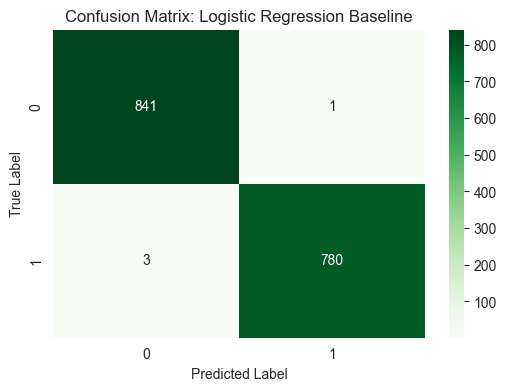

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Print accuracy and detailed classification metrics
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression Baseline')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

K-Fold Cross-Validation

In [5]:
from sklearn.model_selection import cross_validate

# Define the metrics you want to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform 5-fold cross-validation
results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)

# Convert to a DataFrame for a beautiful display in Jupyter
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

# Print the mean of the test metrics
print(f"Mean Test Accuracy: {results_df['test_accuracy'].mean():.4f}")
print(f"Mean Test F1-Score: {results_df['test_f1'].mean():.4f}")

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.020000,0.005000,0.999231,0.996153,0.998408,0.995219,1.000000,0.996808,0.999203,0.996013
1,0.017000,0.004001,0.996923,0.996730,0.998400,0.996410,0.995215,0.996808,0.996805,0.996609
2,0.018001,0.004997,0.996923,0.997500,0.998400,0.998401,0.995215,0.996409,0.996805,0.997404
3,0.020000,0.005000,0.993077,0.997307,0.992026,0.997208,0.993610,0.997208,0.992817,0.997208
4,0.017002,0.004997,0.995381,0.996923,0.993631,0.997206,0.996805,0.996410,0.995215,0.996808


Mean Test Accuracy: 0.9963
Mean Test F1-Score: 0.9962


Permutation Importance check(Robustness)

In [8]:
from sklearn.inspection import permutation_importance
import pandas as pd

# This will take a moment as it re-evaluates the model multiple times
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Organize the results
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(ascending=False, by='importance_mean')

# Print the top 10 features
print(importance_df.head(10))

                     feature  importance_mean  importance_std
20               gill-size_n         0.187015        0.004778
33              stalk-root_b         0.034462        0.002431
19            gill-spacing_w         0.025846        0.003027
32             stalk-shape_t         0.014215        0.002226
68       spore-print-color_h         0.011015        0.001361
54  stalk-color-below-ring_n         0.007815        0.000731
30              gill-color_w         0.007015        0.000788
64               ring-type_f         0.006892        0.000862
70       spore-print-color_n         0.006585        0.001986
63             ring-number_t         0.006031        0.000816
